# AI Valuation — Short Thesis

**Tickers:** NVIDIA (NVDA) · Microsoft (MSFT) · Meta (META) · Palantir (PLTR) · C3.ai (AI)  
**Period:** 2020–2026 | **Data Source:** Yahoo Finance via yfinance | **Stack:** Python · Polars · Matplotlib

---

## Context

The AI boom since 2022 has pushed valuations to historically elevated levels. This analysis selectively examines whether current multiples are justified by fundamentals — and identifies specific short candidates within the sector.

**Thesis:** Not the entire AI sector is overvalued. NVDA and META are fundamentally sound. PLTR and C3.ai, however, trade at multiples that are not justified even under strong growth assumptions.

1. **Performance Analytics** — Who delivered, who didn't?
2. **Fundamental Valuation** — Valuation vs. Growth: where is the premium unjustified?
3. **Forward-Looking Indicators** — Does Smart Money (short interest) confirm our thesis?

In [ ]:
import polars as pl
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

## Setup

Price data from `prices.parquet`, fundamentals from `fundamentals.parquet`, analyst data from `analysts.parquet` — all generated via `00_data_pipeline.ipynb`. All DataFrame operations use **Polars**.

In [6]:
prices = pl.read_parquet("/Users/raphaelzimmermann/tradingbot_v41/quant_analytics/01_market_microstructure/data/thesis/prices.parquet")

In [7]:
prices

date,ticker,close
datetime[ms],str,f64
2020-12-09 00:00:00,"""AI""",92.489998
2020-12-10 00:00:00,"""AI""",130.0
2020-12-11 00:00:00,"""AI""",119.580002
2020-12-14 00:00:00,"""AI""",102.360001
2020-12-15 00:00:00,"""AI""",102.0
…,…,…
2026-02-20 00:00:00,"""PLTR""",135.240005
2026-02-23 00:00:00,"""PLTR""",130.600006
2026-02-24 00:00:00,"""PLTR""",128.839996


In [14]:
AI_TICKERS = ["NVDA", "MSFT", "META", "PLTR", "AI"]


AI = prices.filter(pl.col("ticker").is_in(AI_TICKERS))
print(AI["ticker"].unique())
AI

shape: (5,)
Series: 'ticker' [str]
[
	"NVDA"
	"META"
	"MSFT"
	"PLTR"
	"AI"
]


date,ticker,close
datetime[ms],str,f64
2020-12-09 00:00:00,"""AI""",92.489998
2020-12-10 00:00:00,"""AI""",130.0
2020-12-11 00:00:00,"""AI""",119.580002
2020-12-14 00:00:00,"""AI""",102.360001
2020-12-15 00:00:00,"""AI""",102.0
…,…,…
2026-02-20 00:00:00,"""PLTR""",135.240005
2026-02-23 00:00:00,"""PLTR""",130.600006
2026-02-24 00:00:00,"""PLTR""",128.839996


## Layer 1 — Performance Analytics

Objective: Quantify the historical return and risk profile of AI sector equities.

Important: strong historical performance is **not** a counterargument to a short — it only shows how long a momentum trade can run. What matters is the ratio of return to risk (Sharpe Ratio) and the maximum drawdown.

- **Sharpe Ratio:** `(Ann. Return − RF) / Ann. Volatility` | RF = 3%
- **Max Drawdown:** Measures the worst peak-to-trough loss — a proxy for tail risk

In [18]:
AI = (
    AI
    .sort(["ticker", "date"])
    .with_columns([
        pl.col("close")
          .pct_change()
          .over("ticker")        
          .alias("daily_return")
    ])
    .drop_nulls()
)

AI.head(8)


date,ticker,close,daily_return
datetime[ms],str,f64,f64
2020-12-11 00:00:00,"""AI""",119.580002,-0.080154
2020-12-14 00:00:00,"""AI""",102.360001,-0.144004
2020-12-15 00:00:00,"""AI""",102.0,-0.003517
2020-12-16 00:00:00,"""AI""",113.690002,0.114608
2020-12-17 00:00:00,"""AI""",117.239998,0.031225
2020-12-18 00:00:00,"""AI""",137.589996,0.173576
2020-12-21 00:00:00,"""AI""",160.889999,0.169344
2020-12-22 00:00:00,"""AI""",177.470001,0.103052


In [20]:
AI_cum = (
    AI
    .with_columns([
        (1 + pl.col("daily_return"))
          .cum_prod()
          .over("ticker")
          .alias("cum_return")
    ])
)
AI_cum

date,ticker,close,daily_return,cum_return
datetime[ms],str,f64,f64,f64
2020-12-11 00:00:00,"""AI""",119.580002,-0.080154,0.919846
2020-12-14 00:00:00,"""AI""",102.360001,-0.144004,0.787385
2020-12-15 00:00:00,"""AI""",102.0,-0.003517,0.784615
2020-12-16 00:00:00,"""AI""",113.690002,0.114608,0.874538
2020-12-17 00:00:00,"""AI""",117.239998,0.031225,0.901846
…,…,…,…,…
2026-02-20 00:00:00,"""PLTR""",135.240005,0.002595,14.295984
2026-02-23 00:00:00,"""PLTR""",130.600006,-0.034309,13.805497
2026-02-24 00:00:00,"""PLTR""",128.839996,-0.013476,13.61945


In [ ]:
wide = (
    AI_cum
    .select(["date", "ticker", "cum_return"])
    .pivot(index="date", on="ticker", values="cum_return")
    .sort("date")
)

df_plot = wide.to_pandas().set_index("date")

fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor("#16213e")
ax.set_facecolor("#1a1a2e")

df_plot.plot(ax=ax)
ax.axhline(1.0, color="white", linestyle="--", linewidth=1, alpha=0.5)
ax.set_title("AI Sector — Cumulative Returns (2020–2026)", color="white")
ax.set_ylabel("Value (Indexed to 1.0)", color="white")
ax.tick_params(colors="white")
ax.xaxis.label.set_color("white")
ax.yaxis.label.set_color("white")
ax.legend(loc="upper left", facecolor="#1a1a2e", labelcolor="white")
plt.tight_layout()
plt.show()

In [24]:
RF = 0.03
TRADING_DAYS = 252

metrics = (
    AI
    .group_by("ticker")
    .agg([
        # Annualized Return
        ((1 + pl.col("daily_return")).product() 
            ** (TRADING_DAYS / pl.col("daily_return").count()) - 1
        ).alias("ann_return"),

        # Annualized Volatility — deine Aufgabe: ergänze die Formel
        # Tipp: .std() und np.sqrt(TRADING_DAYS)
        (pl.col("daily_return").std() * np.sqrt(TRADING_DAYS)).alias("ann_volatility"),
    ])
    .with_columns([
        # Sharpe — deine Aufgabe
        ((pl.col("ann_return") - RF) / pl.col("ann_volatility")).alias("sharpe"),
    ])
    .sort("ticker")
)

metrics

ticker,ann_return,ann_volatility,sharpe
str,f64,f64,f64
"""AI""",-0.410311,0.811796,-0.542391
"""META""",0.207234,0.437423,0.405178
"""MSFT""",0.174094,0.298041,0.483471
"""NVDA""",0.755783,0.528453,1.373411
"""PLTR""",0.640977,0.705228,0.866354


In [25]:
max_dd = (
    AI_cum
    .with_columns([
        pl.col("cum_return")
          .cum_max()
          .over("ticker")
          .alias("rolling_max")
    ])
    .with_columns([
        ((pl.col("cum_return") - pl.col("rolling_max")) / pl.col("rolling_max"))
          .alias("drawdown")
    ])
    .group_by("ticker")
    .agg(pl.col("drawdown").min().alias("max_drawdown"))
)

max_dd


ticker,max_drawdown
str,f64
"""AI""",-0.952668
"""META""",-0.767361
"""MSFT""",-0.371485
"""NVDA""",-0.663351
"""PLTR""",-0.846154


In [28]:
join = max_dd.join(metrics, on="ticker").sort("ticker")
print(join)

shape: (5, 5)
┌────────┬──────────────┬────────────┬────────────────┬───────────┐
│ ticker ┆ max_drawdown ┆ ann_return ┆ ann_volatility ┆ sharpe    │
│ ---    ┆ ---          ┆ ---        ┆ ---            ┆ ---       │
│ str    ┆ f64          ┆ f64        ┆ f64            ┆ f64       │
╞════════╪══════════════╪════════════╪════════════════╪═══════════╡
│ AI     ┆ -0.952668    ┆ -0.410311  ┆ 0.811796       ┆ -0.542391 │
│ META   ┆ -0.767361    ┆ 0.207234   ┆ 0.437423       ┆ 0.405178  │
│ MSFT   ┆ -0.371485    ┆ 0.174094   ┆ 0.298041       ┆ 0.483471  │
│ NVDA   ┆ -0.663351    ┆ 0.755783   ┆ 0.528453       ┆ 1.373411  │
│ PLTR   ┆ -0.846154    ┆ 0.640977   ┆ 0.705228       ┆ 0.866354  │
└────────┴──────────────┴────────────┴────────────────┴───────────┘


In [29]:
print(
    join.with_columns([
        (pl.col("ann_return") * 100).round(1).alias("ann_return_%"),
        (pl.col("ann_volatility") * 100).round(1).alias("ann_vol_%"),
        pl.col("sharpe").round(2),
        (pl.col("max_drawdown") * 100).round(1).alias("max_dd_%"),
    ])
    .select(["ticker", "ann_return_%", "ann_vol_%", "sharpe", "max_dd_%"])
)


shape: (5, 5)
┌────────┬──────────────┬───────────┬────────┬──────────┐
│ ticker ┆ ann_return_% ┆ ann_vol_% ┆ sharpe ┆ max_dd_% │
│ ---    ┆ ---          ┆ ---       ┆ ---    ┆ ---      │
│ str    ┆ f64          ┆ f64       ┆ f64    ┆ f64      │
╞════════╪══════════════╪═══════════╪════════╪══════════╡
│ AI     ┆ -41.0        ┆ 81.2      ┆ -0.54  ┆ -95.3    │
│ META   ┆ 20.7         ┆ 43.7      ┆ 0.41   ┆ -76.7    │
│ MSFT   ┆ 17.4         ┆ 29.8      ┆ 0.48   ┆ -37.1    │
│ NVDA   ┆ 75.6         ┆ 52.8      ┆ 1.37   ┆ -66.3    │
│ PLTR   ┆ 64.1         ┆ 70.5      ┆ 0.87   ┆ -84.6    │
└────────┴──────────────┴───────────┴────────┴──────────┘


## Layer 2 — Fundamental Valuation

Objective: Are current valuations justified by company fundamentals?

Core question: **Valuation vs. Growth** — a high P/E is only justified if the company grows at a proportional rate. The classic tool for this is the **PEG Ratio** (`Forward P/E / Revenue Growth`). A PEG > 1 signals overvaluation relative to growth.

The scatter plot "Valuation vs. Growth" makes this tension visually explicit.

In [ ]:
fundamentals = pl.read_parquet("/Users/raphaelzimmermann/tradingbot_v41/quant_analytics/01_market_microstructure/data/thesis/fundamentals.parquet")
ai_fund = fundamentals.filter(pl.col("ticker").is_in(AI_TICKERS))
print(ai_fund)

shape: (5, 10)
┌────────┬────────────┬────────────┬───────────┬───┬───────────┬───────────┬───────────┬───────────┐
│ ticker ┆ market_cap ┆ pe_trailin ┆ pe_forwar ┆ … ┆ revenue_g ┆ free_cash ┆ gross_mar ┆ operating │
│ ---    ┆ ---        ┆ g          ┆ d         ┆   ┆ rowth     ┆ flow      ┆ gin       ┆ _margin   │
│ str    ┆ i64        ┆ ---        ┆ ---       ┆   ┆ ---       ┆ ---       ┆ ---       ┆ ---       │
│        ┆            ┆ f64        ┆ f64       ┆   ┆ f64       ┆ i64       ┆ f64       ┆ f64       │
╞════════╪════════════╪════════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪═══════════╡
│ NVDA   ┆ 4441738575 ┆ 37.21996   ┆ 17.09596  ┆ … ┆ 0.732     ┆ 581289984 ┆ 0.71068   ┆ 0.65024   │
│        ┆ 872        ┆            ┆           ┆   ┆           ┆ 00        ┆           ┆           │
│ MSFT   ┆ 2963958136 ┆ 24.95557   ┆ 21.164682 ┆ … ┆ 0.167     ┆ 536406261 ┆ 0.68586   ┆ 0.47094   │
│        ┆ 832        ┆            ┆           ┆   ┆           ┆ 76        ┆

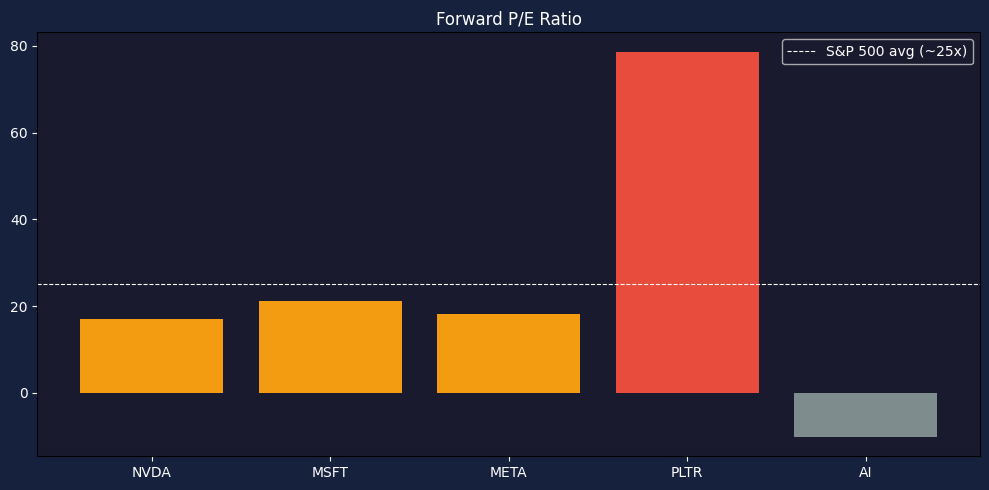

In [33]:
tickers_f  = ai_fund["ticker"].to_list()
pe_forward = ai_fund["pe_forward"].to_list()

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor("#16213e")
ax.set_facecolor("#1a1a2e")

colors = ["#e74c3c" if pe and pe > 50 else "#f39c12" if pe and pe > 0 else "#7f8c8d"
          for pe in pe_forward]

ax.bar(tickers_f, pe_forward, color=colors)
ax.axhline(25, color="white", linewidth=0.8, linestyle="--", label="S&P 500 avg (~25x)")
ax.set_title("Forward P/E Ratio", color="white")
ax.tick_params(colors="white")
ax.legend(facecolor="#1a1a2e", labelcolor="white")
plt.tight_layout()
plt.show()


## Layer 3 — Forward-Looking Indicators

Objective: Analyze market expectations and institutional investor positioning.

- **Analyst Consensus & Price Targets:** Shows the sell-side expected range (Low/Mean/High)
- **Short Interest:** % of float sold short — the most important signal in this layer. A high value indicates institutional investors (hedge funds etc.) are already positioned short.
  > *Risk: High short interest increases squeeze potential on positive surprises.*

# Investment Summary — AI Valuation Short

## The Pitch

This is not a sector short. NVDA at 17x forward P/E with 73% revenue growth is cheap. The short is selective: PLTR at 78x forward P/E with the same growth rate as NVDA, and C3.ai with −46% revenue growth and 31.7% short interest.

---

## The Case

| Ticker | Fwd PE | Rev Growth | Short Interest | Verdict |
|--------|--------|------------|----------------|---------|
| NVDA | **17x** | +73% | 1.1% | Fair value — pass |
| MSFT | 21x | +17% | 0.8% | Stable — pass |
| META | 18x | +24% | 1.2% | Reasonable — pass |
| **PLTR** | **78x** | +70% | 2.4% | **Short: 4.6× premium vs. NVDA, same growth** |
| **AI** | neg. | **−46%** | **31.7%** | **Short: broken business, institutions already in** |

---

## The Number That Matters

PLTR trades at **4.6× the valuation multiple of NVDA** for essentially the same revenue growth. C3.ai has **31.7% short interest** — that's institutional conviction, not retail noise.

## Risks
- **Short squeeze:** 31.7% short interest means a single catalyst creates violent covering
- **Momentum:** *"The market can remain irrational longer than you can remain solvent"* — Keynes
- **PLTR execution:** Accelerating growth could compress the multiple organically

## Bottom Line

Short PLTR and C3.ai. Pass on NVDA and META. These are narrative-driven names — timing matters more than being right.